In [1]:
import pandas
import os

# This query represents dataset "Baseline_Labs_Vitals_LongFormat" for domain "measurement" and was generated for All of Us Controlled Tier Dataset v8
dataset_41258121_measurement_sql = """
    SELECT
        measurement.person_id,
        measurement.measurement_concept_id,
        m_standard_concept.concept_name as standard_concept_name,
        measurement.measurement_datetime,
        measurement.value_as_number,
        m_unit.concept_name as unit_concept_name 
    FROM
        ( SELECT
            measurement.person_id,
            measurement.measurement_concept_id,
            measurement.measurement_datetime,
            measurement.value_as_number,
            measurement.unit_concept_id 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.measurement` measurement 
        WHERE
            (
                measurement_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (3004249, 3004410, 3005673, 3012888, 3016723, 3019550, 3020149, 3024561, 3038553, 40765040, 40795725)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 1 
                    AND is_selectable = 1)
            )  
            AND (
                measurement.PERSON_ID IN (SELECT
                    distinct person_id  
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_person` cb_search_person  
                WHERE
                    cb_search_person.person_id IN (SELECT
                        person_id 
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_person` p 
                    WHERE
                        DATE_DIFF(CURRENT_DATE, dob, YEAR) - IF(EXTRACT(MONTH FROM dob)*100 + EXTRACT(DAY FROM dob) > EXTRACT(MONTH FROM CURRENT_DATE)*100 + EXTRACT(DAY FROM CURRENT_DATE), 1, 0) BETWEEN 50 AND 125 
                        AND NOT EXISTS (      SELECT
                            'x'      
                        FROM
                            `""" + os.environ["WORKSPACE_CDR"] + """.death` d      
                        WHERE
                            d.person_id = p.person_id ) ) 
                    AND cb_search_person.person_id IN (SELECT
                        person_id 
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_person` p 
                    WHERE
                        has_ehr_data = 1 ) )
            )) measurement 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` m_standard_concept 
            ON measurement.measurement_concept_id = m_standard_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` m_unit 
            ON measurement.unit_concept_id = m_unit.concept_id
    WHERE

    (
        -- BMI
        (m_standard_concept.concept_name = 'Body mass index (BMI) [Ratio]'
            AND m_unit.concept_name IN ('kilogram per square meter', 'kg/sq. m')
            AND measurement.value_as_number BETWEEN 10 AND 80)

        OR

        -- Systolic
        (m_standard_concept.concept_name = 'Systolic blood pressure'
            AND m_unit.concept_name = 'millimeter mercury column'
            AND measurement.value_as_number BETWEEN 70 AND 250)

        OR

        -- Diastolic
        (m_standard_concept.concept_name = 'Diastolic blood pressure'
            AND m_unit.concept_name = 'millimeter mercury column'
            AND measurement.value_as_number BETWEEN 40 AND 150)

        OR

        -- Sodium
        (m_standard_concept.concept_name = 'Sodium [Moles/volume] in Serum or Plasma'
            AND m_unit.concept_name = 'millimole per liter'
            AND measurement.value_as_number BETWEEN 110 AND 170)

        OR

        -- Creatinine
        (m_standard_concept.concept_name = 'Creatinine [Mass/volume] in Serum or Plasma'
            AND m_unit.concept_name = 'milligram per deciliter'
            AND measurement.value_as_number BETWEEN 0.2 AND 15)

        OR

        -- Hemoglobin
        (m_standard_concept.concept_name = 'Hemoglobin [Mass/volume] in Blood'
            AND m_unit.concept_name = 'gram per liter'
            AND measurement.value_as_number BETWEEN 50 AND 200)

        OR

        -- Albumin
        (m_standard_concept.concept_name = 'Albumin [Mass/volume] in Serum or Plasma'
            AND m_unit.concept_name = 'gram per liter'
            AND measurement.value_as_number BETWEEN 10 AND 60)

        OR

        -- HbA1c
        (m_standard_concept.concept_name LIKE 'Hemoglobin A1c%'
            AND m_unit.concept_name LIKE '%percent%'
            AND measurement.value_as_number BETWEEN 3 AND 18)

        OR

        -- Vitamin D
        (LOWER(m_standard_concept.concept_name) LIKE '25-%vitamin%'
            AND m_unit.concept_name = 'nanogram per milliliter'
            AND measurement.value_as_number BETWEEN 5 AND 150)
    )
    """

dataset_41258121_measurement_df = pandas.read_gbq(
    dataset_41258121_measurement_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_41258121_measurement_df.shape

Downloading:   0%|          | 0/38293581 [00:00<?, ?rows/s]

(38293581, 6)

In [2]:
dataset_41258121_measurement_df.to_parquet(
    "measurement_raw_cleaned.parquet",
    index=False
)

In [3]:
del dataset_41258121_measurement_df
import gc
gc.collect()

507

In [5]:
import pandas
import os

# This query represents dataset "Mobility_Decline_Events" for domain "condition" and was generated for All of Us Controlled Tier Dataset v8
dataset_40664257_condition_sql = """
    SELECT
        c_occurrence.person_id,
        c_standard_concept.concept_name as standard_concept_name,
        c_occurrence.condition_start_datetime 
    FROM
        ( SELECT
            * 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.condition_occurrence` c_occurrence 
        WHERE
            (
                condition_source_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (35211327, 45548959, 45552105, 45585587, 45587018)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 0 
                    AND is_selectable = 1)
            )  
            AND (
                c_occurrence.PERSON_ID IN (SELECT
                    distinct person_id  
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_person` cb_search_person  
                WHERE
                    cb_search_person.person_id IN (SELECT
                        criteria.person_id 
                    FROM
                        (SELECT
                            DISTINCT person_id, entry_date, concept_id 
                        FROM
                            `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_all_events` 
                        WHERE
                            (concept_id IN(SELECT
                                DISTINCT c.concept_id 
                            FROM
                                `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                            JOIN
                                (SELECT
                                    CAST(cr.id as string) AS id       
                                FROM
                                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                                WHERE
                                    concept_id IN (45553724, 45552105, 35211327, 45587018, 45548959, 21057)       
                                    AND full_text LIKE '%_rank1]%'      ) a 
                                    ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                                    OR c.path LIKE CONCAT('%.', a.id) 
                                    OR c.path LIKE CONCAT(a.id, '.%') 
                                    OR c.path = a.id) 
                            WHERE
                                is_standard = 0 
                                AND is_selectable = 1) 
                            AND is_standard = 0 )) criteria ) )
            )) c_occurrence 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` c_standard_concept 
            ON c_occurrence.condition_concept_id = c_standard_concept.concept_id"""

dataset_40664257_condition_df = pandas.read_gbq(
    dataset_40664257_condition_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_40664257_condition_df.shape

Downloading:   0%|          | 0/269192 [00:00<?, ?rows/s]

(269192, 3)

In [6]:
dataset_40664257_condition_df.to_parquet(
    "mobility_condition_raw.parquet",
    index=False
)

In [7]:
del dataset_40664257_condition_df
gc.collect()

865

In [6]:
import pandas as pd

measurement_df = pd.read_parquet("measurement_raw_cleaned.parquet")
mobility_df = pd.read_parquet("mobility_condition_raw.parquet")

In [9]:
measurement_df.memory_usage(deep=True).sum() / 1e9

7.66826447

## Define TRUE CASE INDEX DATES

In [8]:
mobility_first = (
    mobility_df
    .groupby("person_id")["condition_start_datetime"]
    .min()
    .reset_index()
)

mobility_first = mobility_first.rename(
    columns={"condition_start_datetime": "decline_date"}
)

mobility_first.to_parquet("mobility_first_index.parquet", index=False)

In [9]:
mobility_first.shape

(36787, 2)

## Restrict to Cases Who Have Labs

In [10]:
lab_ids = set(measurement_df["person_id"].unique())
case_ids = set(mobility_first["person_id"])

case_ids_with_labs = case_ids & lab_ids

len(case_ids_with_labs)

29537

In [11]:
cases_df = mobility_first[
    mobility_first["person_id"].isin(case_ids_with_labs)
].copy()

cases_df["label"] = 1

cases_df.shape

(29537, 3)

## Define CLEAN CONTROL POOL

In [12]:
control_ids = lab_ids - case_ids_with_labs

len(control_ids)

222929

In [13]:
controls_df = pd.DataFrame({
    "person_id": list(control_ids),
    "label": 0
})

controls_df.shape

(222929, 2)

## Build Observation Windows

In [14]:
observation_windows = (
    measurement_df
    .groupby("person_id")["measurement_datetime"]
    .agg(["min", "max"])
    .reset_index()
)

observation_windows.columns = [
    "person_id",
    "first_lab",
    "last_lab"
]

observation_windows.shape

(252466, 3)

In [15]:
observation_windows.to_parquet("observation_windows.parquet", index=False)

## Build Random Pseudo-Index for Controls

In [16]:
# Merge observation windows into controls
controls_df = controls_df.merge(
    observation_windows,
    on="person_id",
    how="left"
)

controls_df.shape

(222929, 4)

In [17]:
# Generate Random Pseudo Index Date
import numpy as np

np.random.seed(42)

# Convert to datetime (safety)
controls_df["first_lab"] = pd.to_datetime(controls_df["first_lab"])
controls_df["last_lab"]  = pd.to_datetime(controls_df["last_lab"])

# Compute days between first and last
controls_df["window_days"] = (
    controls_df["last_lab"] - controls_df["first_lab"]
).dt.days

# Remove those with zero-day window
controls_df = controls_df[controls_df["window_days"] > 0]

# Random offset
controls_df["random_offset"] = np.random.randint(
    0,
    controls_df["window_days"] + 1
)

controls_df["decline_date"] = (
    controls_df["first_lab"] +
    pd.to_timedelta(controls_df["random_offset"], unit="D")
)

controls_df.shape

(182608, 7)

## Final Case + Control Cohort

In [18]:
#Merge observation windows into cases for filtering:
cases_df = cases_df.merge(
    observation_windows,
    on="person_id",
    how="left"
)

cases_df.shape

(29537, 5)

In [19]:
pseudo_cohort = pd.concat(
    [
        cases_df[["person_id", "decline_date", "label"]],
        controls_df[["person_id", "decline_date", "label"]]
    ],
    ignore_index=True
)

pseudo_cohort.shape

(212145, 3)

In [20]:
pseudo_cohort.to_parquet("pseudo_cohort.parquet", index=False)

In [22]:
pseudo_cohort["label"].value_counts(normalize=True)

label
0    0.86077
1    0.13923
Name: proportion, dtype: float64

In [23]:
pseudo_cohort["decline_date"].isna().sum()

0

## Missingness Analysis

Examine whether measurement availability differs systematically between cases and controls. Differential missingness may indicate ascertainment bias (sicker patients receive more labs).

In [2]:
# Merge labs with pseudo cohort to assess missingness
labs_for_missing = measurement_df.merge(
    pseudo_cohort, on="person_id", how="inner"
)

labs_for_missing["measurement_datetime"] = pd.to_datetime(labs_for_missing["measurement_datetime"])
labs_for_missing["decline_date"] = pd.to_datetime(labs_for_missing["decline_date"])

# Restrict to pre-index, 3-year window
labs_for_missing = labs_for_missing[
    (labs_for_missing["measurement_datetime"] < labs_for_missing["decline_date"]) &
    (labs_for_missing["measurement_datetime"] >= labs_for_missing["decline_date"] - pd.DateOffset(years=3))
]

# Pivot to wide: one row per person, one col per lab type (mean)
wide_for_missing = (
    labs_for_missing
    .groupby(["person_id", "standard_concept_name"])["value_as_number"]
    .mean()
    .unstack()
    .reset_index()
)

wide_for_missing = wide_for_missing.merge(
    pseudo_cohort[["person_id", "label"]], on="person_id", how="left"
)

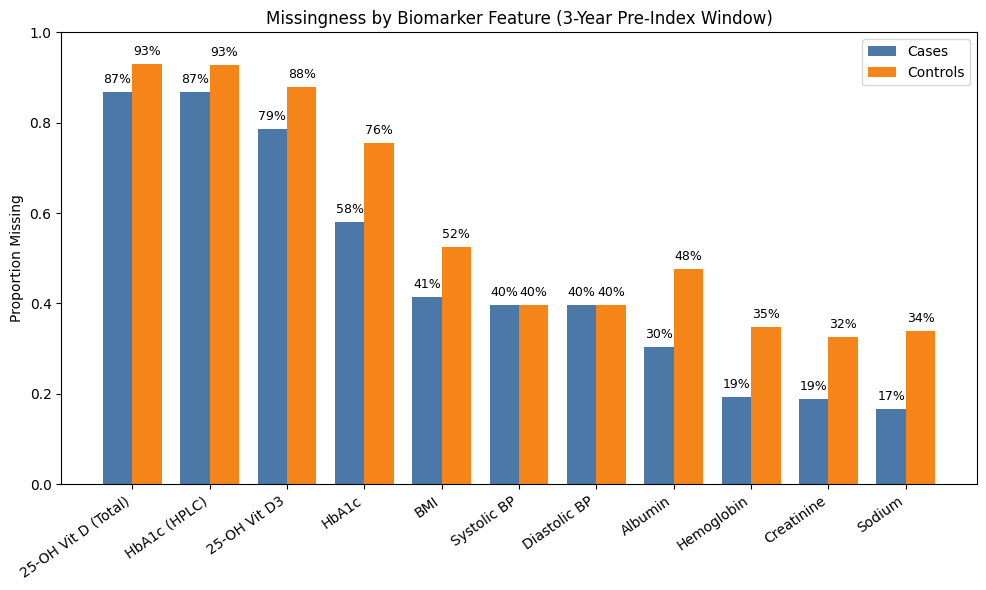

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feature_cols = [c for c in wide_for_missing.columns if c not in ["person_id", "label"]]

# Compute missingness by group
missing_by_label = pd.DataFrame({
    "Cases": wide_for_missing[wide_for_missing["label"] == 1][feature_cols].isna().mean(),
    "Controls": wide_for_missing[wide_for_missing["label"] == 0][feature_cols].isna().mean()
})

missing_by_label = missing_by_label.sort_values("Cases", ascending=False)

# Shorter labels for publication
rename_map = {
    "25-Hydroxyvitamin D3+25-Hydroxyvitamin D2 [Mass/volume] in Serum or Plasma": "25-OH Vit D (Total)",
    "25-hydroxyvitamin D3 [Mass/volume] in Serum or Plasma": "25-OH Vit D3",
    "Hemoglobin A1c/Hemoglobin.total in Blood by HPLC": "HbA1c (HPLC)",
    "Hemoglobin A1c/Hemoglobin.total in Blood": "HbA1c",
    "Body mass index (BMI) [Ratio]": "BMI",
    "Systolic blood pressure": "Systolic BP",
    "Diastolic blood pressure": "Diastolic BP",
    "Albumin [Mass/volume] in Serum or Plasma": "Albumin",
    "Hemoglobin [Mass/volume] in Blood": "Hemoglobin",
    "Creatinine [Mass/volume] in Serum or Plasma": "Creatinine",
    "Sodium [Moles/volume] in Serum or Plasma": "Sodium"
}

missing_by_label.index = [rename_map.get(i, i) for i in missing_by_label.index]

# Plot
fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(missing_by_label))
width = 0.38

bars1 = ax.bar(x - width/2, missing_by_label["Cases"], width, label="Cases", color="#4C78A8")
bars2 = ax.bar(x + width/2, missing_by_label["Controls"], width, label="Controls", color="#F58518")

# Labels
ax.set_ylabel("Proportion Missing")
ax.set_title("Missingness by Biomarker Feature (3-Year Pre-Index Window)")
ax.set_xticks(x)
ax.set_xticklabels(missing_by_label.index, rotation=35, ha="right")

ax.set_ylim(0,1)
ax.legend()

# Percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.02,
                f"{h*100:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("missingness_clean.png", dpi=300)
plt.show()

**Interpretation:** If missingness rates are substantially higher in controls (who have pseudo-random index dates that may fall early in their observation window), this confirms that measurement frequency is partly an artifact of study design rather than a pure biological signal. This motivates the sensitivity analysis removing count features (see below).

## Merge Labs with Pseudo Cohort

In [24]:
labs = measurement_df.merge(
    pseudo_cohort,
    on="person_id",
    how="inner"
)

labs.shape

(38020365, 8)

## Remove Leakage

In [25]:
labs["measurement_datetime"] = pd.to_datetime(labs["measurement_datetime"])
labs["decline_date"] = pd.to_datetime(labs["decline_date"])

labs_preindex = labs[
    labs["measurement_datetime"] < labs["decline_date"]
].copy()

labs_preindex.shape

(17575199, 8)

In [26]:
labs_preindex.to_parquet("labs_preindex_pseudo.parquet", index=False)

## Create 2-Year and 3-Year Windows

In [27]:
# 2-yr 
labs_2yr = labs_preindex[
    labs_preindex["measurement_datetime"] >=
    labs_preindex["decline_date"] - pd.DateOffset(years=2)
].copy()

labs_2yr.shape

(7379592, 8)

In [28]:
labs_2yr.to_parquet("labs_2yr_pseudo.parquet", index=False)

In [29]:
#3-yr
labs_3yr = labs_preindex[
    labs_preindex["measurement_datetime"] >=
    labs_preindex["decline_date"] - pd.DateOffset(years=3)
].copy()

labs_3yr.shape

(9709259, 8)

In [30]:
labs_3yr.to_parquet("labs_3yr_pseudo.parquet", index=False)

In [31]:
print("Unique persons 2yr:", labs_2yr["person_id"].nunique())
print("Unique persons 3yr:", labs_3yr["person_id"].nunique())
print("Total pseudo cohort:", pseudo_cohort["person_id"].nunique())

Unique persons 2yr: 186914
Unique persons 3yr: 196608
Total pseudo cohort: 212145


In [32]:
labs_2yr[["person_id","label"]].drop_duplicates()["label"].value_counts()

label
0    159772
1     27142
Name: count, dtype: int64

In [33]:
labs_3yr[["person_id","label"]].drop_duplicates()["label"].value_counts()

label
0    168861
1     27747
Name: count, dtype: int64

2-Year Design

N = 186,914
Cases = 27,142 (~14.5%)

3-Year Design

N = 196,608
Cases = 27,747 (~14.1%)

## Build Baseline Features (2yr + 3yr)

In [34]:
# 2-yr baseline
baseline_2yr = (
    labs_2yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(mean_value=("value_as_number", "mean"))
    .reset_index()
)

baseline_2yr_wide = baseline_2yr.pivot(
    index="person_id",
    columns="standard_concept_name",
    values="mean_value"
).reset_index()

baseline_2yr_wide = baseline_2yr_wide.merge(
    labs_2yr[["person_id","label"]].drop_duplicates(),
    on="person_id",
    how="left"
)

baseline_2yr_wide.shape

(186914, 13)

In [35]:
baseline_2yr_wide.to_parquet("baseline_2yr_wide.parquet", index=False)

In [36]:
# 3-yr baseline
baseline_3yr = (
    labs_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(mean_value=("value_as_number", "mean"))
    .reset_index()
)

baseline_3yr_wide = baseline_3yr.pivot(
    index="person_id",
    columns="standard_concept_name",
    values="mean_value"
).reset_index()

baseline_3yr_wide = baseline_3yr_wide.merge(
    labs_3yr[["person_id","label"]].drop_duplicates(),
    on="person_id",
    how="left"
)

baseline_3yr_wide.shape

(196608, 13)

In [37]:
baseline_3yr_wide.to_parquet("baseline_3yr_wide.parquet", index=False)

## 5-Fold CV on baseline features

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

def run_model_cv(df, model_name="Model", n_splits=5, random_state=42):

    X = df.drop(columns=["person_id", "label"])
    y = df["label"]

    # Remove rows where all features missing
    mask = ~X.isna().all(axis=1)
    X = X[mask]
    y = y[mask]

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    aucs = []

    print(f"\n===== {model_name} =====")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train_raw = X.iloc[train_idx]
        X_test_raw  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(X_train_raw)
        X_test  = imputer.transform(X_test_raw)

        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        model = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbose=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred)

        aucs.append(auc)
        print(f"Fold {fold}: AUC = {auc:.4f}")

    mean_auc = np.mean(aucs)
    std_auc  = np.std(aucs)

    print(f"\nMean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

    return mean_auc, std_auc

In [6]:
b2_mean, b2_std = run_model_cv(
    baseline_2yr_wide,
    model_name="Pseudo Baseline 2-Year"
)


===== Pseudo Baseline 2-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7139


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7182


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3: AUC = 0.7152


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.7135
Fold 5: AUC = 0.7148

Mean AUC: 0.7151 ± 0.0016


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
b3_mean, b3_std = run_model_cv(
    baseline_3yr_wide,
    model_name="Pseudo Baseline 3-Year"
)


===== Pseudo Baseline 3-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7270


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7240


...

Fold 3: AUC = 0.7318


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.7273


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.7229

Mean AUC: 0.7266 ± 0.0031


## Build Trajectory Features (with Slope)

Trajectory features capture longitudinal dynamics beyond cross-sectional means:
- **mean**: average value in the observation window
- **std**: within-person variability
- **delta**: last − first value (total change)
- **slope**: linear regression slope of value vs. days-before-index (rate of change per day)
- **count**: number of measurements (utilization proxy)

In [8]:
# ── 2-Year Trajectory Features (with slope) ─────────────────────────────────
import numpy as np

labs_2yr["measurement_datetime"] = pd.to_datetime(labs_2yr["measurement_datetime"])
labs_2yr["decline_date"] = pd.to_datetime(labs_2yr["decline_date"])

labs_2yr["days_before_index"] = (
    labs_2yr["decline_date"] - labs_2yr["measurement_datetime"]
).dt.days

labs_2yr = labs_2yr.sort_values(
    ["person_id", "standard_concept_name", "measurement_datetime"]
)

# Basic aggregation
agg_basic_2yr = (
    labs_2yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        mean=("value_as_number", "mean"),
        std=("value_as_number", "std"),
        first_val=("value_as_number", "first"),
        last_val=("value_as_number", "last"),
        count=("value_as_number", "count")
    )
)

# Slope via vectorized covariance method
labs_2yr["xy"] = labs_2yr["days_before_index"] * labs_2yr["value_as_number"]
labs_2yr["xx"] = labs_2yr["days_before_index"] ** 2

agg_slope_2yr = (
    labs_2yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        sum_x=("days_before_index", "sum"),
        sum_y=("value_as_number", "sum"),
        sum_xy=("xy", "sum"),
        sum_xx=("xx", "sum"),
        n=("value_as_number", "count")
    )
)

numerator = agg_slope_2yr["n"] * agg_slope_2yr["sum_xy"] - agg_slope_2yr["sum_x"] * agg_slope_2yr["sum_y"]
denominator = agg_slope_2yr["n"] * agg_slope_2yr["sum_xx"] - agg_slope_2yr["sum_x"] ** 2

agg_slope_2yr["slope"] = numerator / denominator
agg_slope_2yr.loc[denominator == 0, "slope"] = np.nan

# Combine
trajectory_2yr = agg_basic_2yr.join(agg_slope_2yr["slope"])
trajectory_2yr["delta"] = trajectory_2yr["last_val"] - trajectory_2yr["first_val"]
trajectory_2yr = trajectory_2yr.reset_index()

print("2yr trajectory shape:", trajectory_2yr.shape)

2yr trajectory shape: (874518, 9)


In [9]:
# Pivot 2yr to wide format
traj_2yr_long = trajectory_2yr.melt(
    id_vars=["person_id", "standard_concept_name"],
    value_vars=["mean", "std", "delta", "slope", "count"],
    var_name="metric",
    value_name="value"
)

traj_2yr_long["feature"] = (
    traj_2yr_long["standard_concept_name"]
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    + "_" + traj_2yr_long["metric"]
)

traj_2yr_wide = traj_2yr_long.pivot(
    index="person_id",
    columns="feature",
    values="value"
).reset_index()

traj_2yr_wide = traj_2yr_wide.merge(
    labs_2yr[["person_id", "label"]].drop_duplicates(),
    on="person_id", how="left"
)

traj_2yr_wide.to_parquet("traj_2yr_wide.parquet", index=False)
print("2yr trajectory wide shape:", traj_2yr_wide.shape)

2yr trajectory wide shape: (186914, 57)


In [10]:
traj_2yr_wide.to_parquet("traj_2yr_wide.parquet", index=False)

In [11]:
# ── 3-Year Trajectory Features (with slope) ─────────────────────────────────

labs_3yr["measurement_datetime"] = pd.to_datetime(labs_3yr["measurement_datetime"])
labs_3yr["decline_date"] = pd.to_datetime(labs_3yr["decline_date"])

labs_3yr["days_before_index"] = (
    labs_3yr["decline_date"] - labs_3yr["measurement_datetime"]
).dt.days

labs_3yr = labs_3yr.sort_values(
    ["person_id", "standard_concept_name", "measurement_datetime"]
)

# Basic aggregation
agg_basic_3yr = (
    labs_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        mean=("value_as_number", "mean"),
        std=("value_as_number", "std"),
        first_val=("value_as_number", "first"),
        last_val=("value_as_number", "last"),
        count=("value_as_number", "count")
    )
)

# Slope
labs_3yr["xy"] = labs_3yr["days_before_index"] * labs_3yr["value_as_number"]
labs_3yr["xx"] = labs_3yr["days_before_index"] ** 2

agg_slope_3yr = (
    labs_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        sum_x=("days_before_index", "sum"),
        sum_y=("value_as_number", "sum"),
        sum_xy=("xy", "sum"),
        sum_xx=("xx", "sum"),
        n=("value_as_number", "count")
    )
)

num_3yr = agg_slope_3yr["n"] * agg_slope_3yr["sum_xy"] - agg_slope_3yr["sum_x"] * agg_slope_3yr["sum_y"]
den_3yr = agg_slope_3yr["n"] * agg_slope_3yr["sum_xx"] - agg_slope_3yr["sum_x"] ** 2

agg_slope_3yr["slope"] = num_3yr / den_3yr
agg_slope_3yr.loc[den_3yr == 0, "slope"] = np.nan

trajectory_3yr = agg_basic_3yr.join(agg_slope_3yr["slope"])
trajectory_3yr["delta"] = trajectory_3yr["last_val"] - trajectory_3yr["first_val"]
trajectory_3yr = trajectory_3yr.reset_index()

print("3yr trajectory shape:", trajectory_3yr.shape)

3yr trajectory shape: (956317, 9)


In [12]:
# Pivot 3yr to wide format
traj_3yr_long = trajectory_3yr.melt(
    id_vars=["person_id", "standard_concept_name"],
    value_vars=["mean", "std", "delta", "slope", "count"],
    var_name="metric",
    value_name="value"
)

traj_3yr_long["feature"] = (
    traj_3yr_long["standard_concept_name"]
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    + "_" + traj_3yr_long["metric"]
)

traj_3yr_wide = traj_3yr_long.pivot(
    index="person_id",
    columns="feature",
    values="value"
).reset_index()

traj_3yr_wide = traj_3yr_wide.merge(
    labs_3yr[["person_id", "label"]].drop_duplicates(),
    on="person_id", how="left"
)

traj_3yr_wide.to_parquet("traj_3yr_wide.parquet", index=False)
print("3yr trajectory wide shape:", traj_3yr_wide.shape)

3yr trajectory wide shape: (196608, 57)


In [13]:
traj_3yr_wide.to_parquet("traj_3yr_wide.parquet", index=False)

## 5-Fold CV on Trajectory Models

In [14]:
t2_mean, t2_std = run_model_cv(
    traj_2yr_wide,
    model_name="Pseudo Trajectory 2-Year"
)

t3_mean, t3_std = run_model_cv(
    traj_3yr_wide,
    model_name="Pseudo Trajectory 3-Year"
)


===== Pseudo Trajectory 2-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7594


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7618


...

Fold 3: AUC = 0.7717


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.7764


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.7669

Mean AUC: 0.7708 ± 0.0032


In [15]:
## Multi-Model Comparison (Baseline vs Trajectory)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

def run_multiple_models_cv(df, label="Dataset"):

    from sklearn.model_selection import StratifiedKFold
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import roc_auc_score
    import numpy as np

    X = df.drop(columns=["person_id","label"])
    y = df["label"]

    mask = ~X.isna().all(axis=1)
    X = X[mask]
    y = y[mask]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1),
        "XGBoost": xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, eval_metric="auc", use_label_encoder=False),
        "LightGBM": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05)
    }

    print(f"\n===== {label} =====")

    for name, model in models.items():

        aucs = []

        for train_idx, test_idx in skf.split(X,y):

            X_train_raw = X.iloc[train_idx]
            X_test_raw  = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test  = y.iloc[test_idx]

            imputer = SimpleImputer(strategy="median")
            X_train = imputer.fit_transform(X_train_raw)
            X_test  = imputer.transform(X_test_raw)

            if name == "Logistic Regression":
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)

            scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()

            if name == "LightGBM":
                model.set_params(scale_pos_weight=scale_pos_weight)
            if name == "XGBoost":
                model.set_params(scale_pos_weight=scale_pos_weight)

            model.fit(X_train,y_train)
            y_pred = model.predict_proba(X_test)[:,1]

            aucs.append(roc_auc_score(y_test,y_pred))

        print(f"{name}: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

In [17]:
run_multiple_models_cv(baseline_3yr_wide, "Pseudo Baseline 3yr")
run_multiple_models_cv(traj_3yr_wide, "Pseudo Trajectory 3yr")


===== Pseudo Baseline 3yr =====
Logistic Regression: 0.6191 ± 0.0044
Random Forest: 0.6783 ± 0.0039


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:12:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:12:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:12:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:12:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:12:50] WARNING: /w

XGBoost: 0.7207 ± 0.0033


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.7266 ± 0.0031

===== Pseudo Trajectory 3yr =====
Logistic Regression: 0.7010 ± 0.0066
Random Forest: 0.7517 ± 0.0041


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:15:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:15:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:15:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:15:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:15:57] WARNING: /w

XGBoost: 0.7708 ± 0.0023


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.7708 ± 0.0032


## OOF Prediction for Baseline and Trajectory (3-Year)

In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

def get_oof_predictions(df, random_state=42):

    X = df.drop(columns=["person_id","label"])
    y = df["label"].values

    mask = ~X.isna().all(axis=1)
    X = X[mask]
    y = y[mask]

    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    oof_preds = np.zeros(len(y))

    for train_idx, test_idx in skf.split(X, y):

        X_train_raw = X.iloc[train_idx]
        X_test_raw  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(X_train_raw)
        X_test  = imputer.transform(X_test_raw)

        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        model = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbose=-1
        )

        model.fit(X_train, y_train)

        oof_preds[test_idx] = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y, oof_preds)
    print("OOF AUC:", auc)

    return y.values, oof_preds

In [19]:
y_true_base, preds_base = get_oof_predictions(baseline_3yr_wide)
y_true_traj, preds_traj = get_oof_predictions(traj_3yr_wide)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7265770344559946


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7707807480065922


In [20]:
np.all(y_true_base == y_true_traj)

True

## DeLong Test (Paired)

In [21]:
from scipy import stats
import numpy as np

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N)
    T2[J] = T + 1
    return T2

def fast_delong(predictions, label_1_count):
    m = label_1_count
    n = predictions.shape[1] - m

    positive = predictions[:, :m]
    negative = predictions[:, m:]

    k = predictions.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r, :] = compute_midrank(positive[r, :])
        ty[r, :] = compute_midrank(negative[r, :])
        tz[r, :] = compute_midrank(predictions[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1) / 2 / n

    v01 = (tz[:, :m] - tx) / n
    v10 = 1 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov

def delong_test(y_true, pred1, pred2):

    order = np.argsort(-y_true)
    y_true = y_true[order]
    pred1 = pred1[order]
    pred2 = pred2[order]

    label_1_count = int(np.sum(y_true))

    predictions = np.vstack((pred1, pred2))
    aucs, delongcov = fast_delong(predictions, label_1_count)

    diff = aucs[0] - aucs[1]
    var = delongcov[0,0] + delongcov[1,1] - 2 * delongcov[0,1]
    z = diff / np.sqrt(var)
    p = 2 * (1 - stats.norm.cdf(abs(z)))

    return aucs, diff, p

In [22]:
aucs, diff, p = delong_test(
    y_true_base,
    preds_traj,
    preds_base
)

print("Trajectory AUC:", aucs[0])
print("Baseline AUC:", aucs[1])
print("AUC Difference:", diff)
print("p-value:", p)

Trajectory AUC: 0.7707807480065922
Baseline AUC: 0.7265770344559948
AUC Difference: 0.04420371355059749
p-value: 0.0


## 95% CI From OOF Predictions

In [23]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred, n_bootstrap=2000, random_state=42):

    rng = np.random.RandomState(random_state)
    boot_aucs = []

    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot_aucs.append(
            roc_auc_score(y_true[idx], y_pred[idx])
        )

    boot_aucs = np.array(boot_aucs)

    lower = np.percentile(boot_aucs, 2.5)
    upper = np.percentile(boot_aucs, 97.5)
    mean  = np.mean(boot_aucs)

    return mean, lower, upper

In [24]:
# Baseline 3yr
base_mean, base_lo, base_hi = bootstrap_auc_ci(
    y_true_base, preds_base
)

# Trajectory 3yr
traj_mean, traj_lo, traj_hi = bootstrap_auc_ci(
    y_true_traj, preds_traj
)

print("Baseline 3yr AUC:", round(base_mean,4),
      f"[{base_lo:.4f} – {base_hi:.4f}]")

print("Trajectory 3yr AUC:", round(traj_mean,4),
      f"[{traj_lo:.4f} – {traj_hi:.4f}]")

Baseline 3yr AUC: 0.7266 [0.7234 – 0.7298]
Trajectory 3yr AUC: 0.7708 [0.7679 – 0.7740]


## SHAP Interpretation (3-Year Trajectory Model)

SHAP values are computed on held-out test data to avoid overfitting artifacts.

In [25]:
import shap
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import matplotlib.pyplot as plt

X = traj_3yr_wide.drop(columns=["person_id", "label"])
y = traj_3yr_wide["label"]

mask = ~X.isna().all(axis=1)
X = X[mask]
y = y[mask]

# Train/test split — SHAP computed only on held-out test set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train_raw)
X_test = imputer.transform(X_test_raw)

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

shap_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

shap_model.fit(X_train, y_train)

# SHAP on held-out test set (subsample 5000 if larger)
n_shap = min(5000, len(X_test_df))
X_shap = X_test_df.sample(n=n_shap, random_state=42)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

# Handle binary output (shap_values may be a list [class0, class1])
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1 (decline)
else:
    shap_vals = shap_values

print("SHAP values computed on held-out test set. Shape:", np.array(shap_vals).shape)

SHAP values computed on held-out test set. Shape: (5000, 55)


/home/jupyter/.local/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


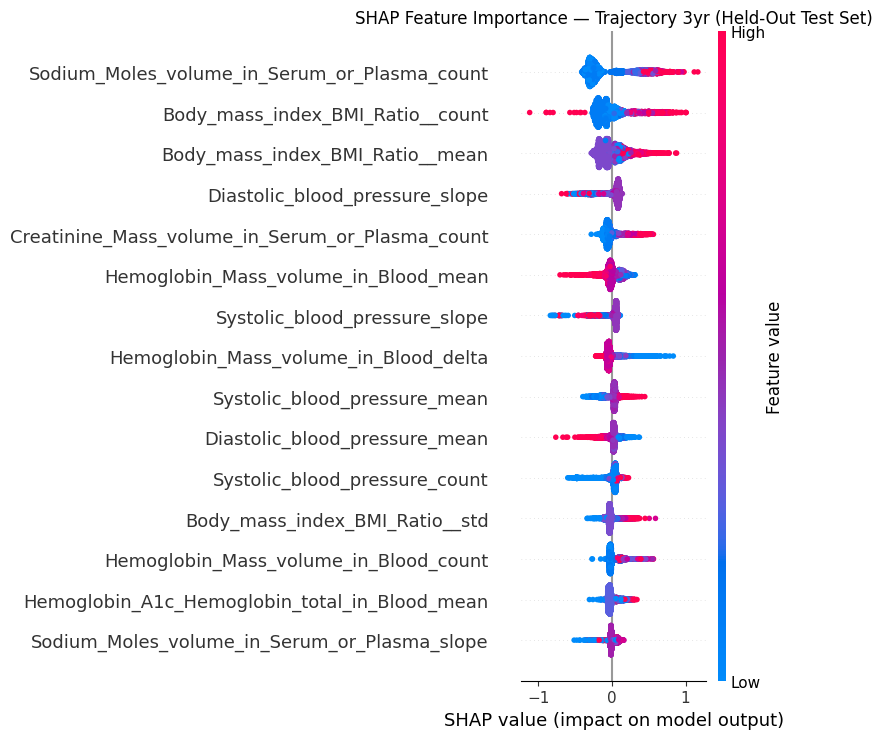

In [26]:
# Beeswarm plot
shap.summary_plot(shap_vals, X_shap, max_display=15, show=False)
plt.title("SHAP Feature Importance — Trajectory 3yr (Held-Out Test Set)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

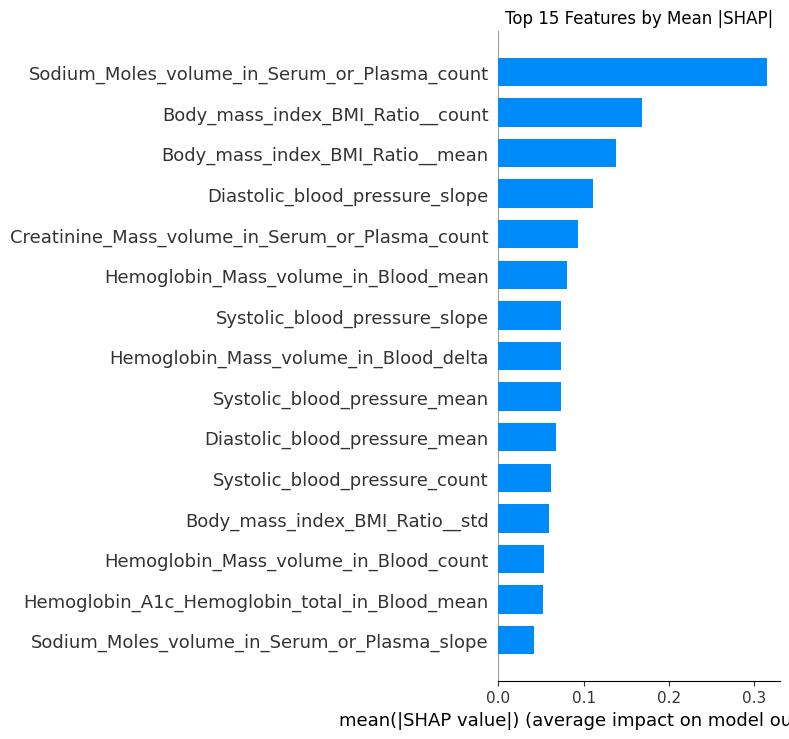

In [27]:
# Mean |SHAP| bar plot
shap.summary_plot(shap_vals, X_shap, plot_type="bar", max_display=15, show=False)
plt.title("Top 15 Features by Mean |SHAP|")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Numeric ranking
mean_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print("\nTop 15 Most Important Features:")
print(mean_shap.head(15).to_string())

# Which metric types dominate?
metric_importance = mean_shap.reset_index()
metric_importance.columns = ["feature", "mean_abs_shap"]
metric_importance["metric"] = metric_importance["feature"].apply(
    lambda x: x.split("_")[-1]
)
print("\nMean |SHAP| by metric type:")
print(metric_importance.groupby("metric")["mean_abs_shap"].mean().sort_values(ascending=False).to_string())


Top 15 Most Important Features:
Sodium_Moles_volume_in_Serum_or_Plasma_count       0.314558
Body_mass_index_BMI_Ratio__count                   0.169022
Body_mass_index_BMI_Ratio__mean                    0.137597
Diastolic_blood_pressure_slope                     0.111226
Creatinine_Mass_volume_in_Serum_or_Plasma_count    0.093566
Hemoglobin_Mass_volume_in_Blood_mean               0.081084
Systolic_blood_pressure_slope                      0.073690
Hemoglobin_Mass_volume_in_Blood_delta              0.073495
Systolic_blood_pressure_mean                       0.072990
Diastolic_blood_pressure_mean                      0.067632
Systolic_blood_pressure_count                      0.061983
Body_mass_index_BMI_Ratio__std                     0.059039
Hemoglobin_Mass_volume_in_Blood_count              0.053842
Hemoglobin_A1c_Hemoglobin_total_in_Blood_mean      0.051897
Sodium_Moles_volume_in_Serum_or_Plasma_slope       0.041354

Mean |SHAP| by metric type:
metric
count    0.072359
mean     0.05

## Sensitivity Analysis: Removing Count Features

Count features may proxy for healthcare utilization rather than biological signal. This analysis tests whether predictive performance persists after their removal.

In [29]:
features_no_count = [
    col for col in traj_3yr_wide.columns
    if not col.endswith("_count")
]

traj_3yr_no_count = traj_3yr_wide[features_no_count]

y_true_nc, preds_nc = get_oof_predictions(traj_3yr_no_count)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7629208572340074


In [30]:
nc_mean, nc_lo, nc_hi = bootstrap_auc_ci(y_true_nc, preds_nc)

print("Trajectory 3yr (No Count) AUC:",
      round(nc_mean,4),
      f"[{nc_lo:.4f} – {nc_hi:.4f}]")

Trajectory 3yr (No Count) AUC: 0.763 [0.7600 – 0.7661]


In [31]:
aucs_nc, diff_nc, p_nc = delong_test(
    y_true_traj,
    preds_traj,
    preds_nc
)

print("Full model AUC:", round(aucs_nc[0], 4))
print("No-count AUC:", round(aucs_nc[1], 4))
print("Difference:", round(diff_nc, 4))
print("DeLong p-value:", round(p_nc, 6))

Full model AUC: 0.7708
No-count AUC: 0.7629
Difference: 0.0079
DeLong p-value: 0.0


Although healthcare utilization (measurement frequency) contributed modestly to discrimination, the majority of predictive gain persisted after removal of count features, suggesting true biological trajectory effects rather than purely utilization-driven signal.

## Calibration Analysis

Calibration assesses whether predicted probabilities match observed event rates — critical for clinical decision-making.

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Uncalibrated: AUC=0.7742 | Brier=0.1843 | AUPRC=0.4041


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/ut

Isotonic: AUC=0.7746 | Brier=0.1025 | AUPRC=0.4084


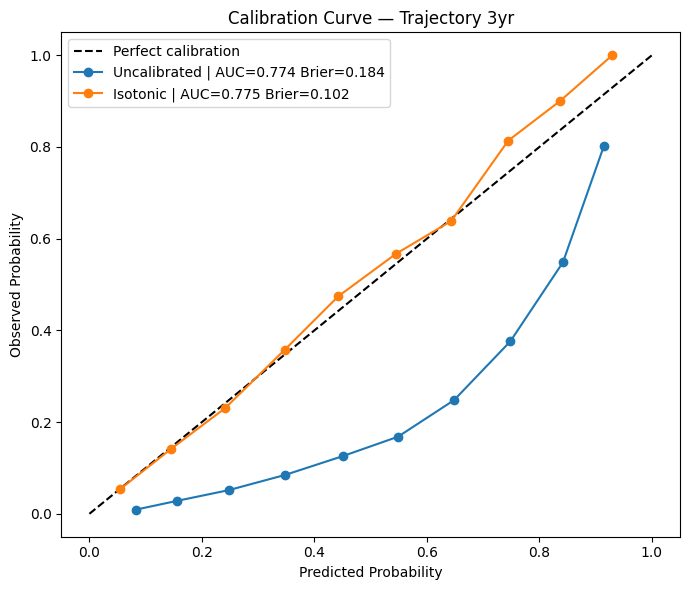

In [32]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

def evaluate_calibration(df, label="Model"):
    """Evaluate discrimination, calibration, and plot calibration curves."""

    X = df.drop(columns=["person_id", "label"])
    y = df["label"]

    mask = ~X.isna().all(axis=1)
    X, y = X[mask], y[mask]

    imputer = SimpleImputer(strategy="median")
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_train = imputer.fit_transform(X_train_raw)
    X_test = imputer.transform(X_test_raw)

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    # Uncalibrated
    base = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        scale_pos_weight=spw, random_state=42, verbose=-1
    )

    # Isotonic-calibrated
    calibrated = CalibratedClassifierCV(
        lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05,
            scale_pos_weight=spw, random_state=42, verbose=-1
        ),
        method="isotonic", cv=5
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

    for name, model in [("Uncalibrated", base), ("Isotonic", calibrated)]:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_prob)
        brier = brier_score_loss(y_test, y_prob)
        auprc = average_precision_score(y_test, y_prob)

        prob_true, prob_pred = calibration_curve(
            y_test, y_prob, n_bins=10, strategy="uniform"
        )

        ax.plot(prob_pred, prob_true, marker="o",
                label=f"{name} | AUC={auc:.3f} Brier={brier:.3f}")

        print(f"{name}: AUC={auc:.4f} | Brier={brier:.4f} | AUPRC={auprc:.4f}")

    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Observed Probability")
    ax.set_title(f"Calibration Curve — {label}")
    ax.legend()
    plt.tight_layout()
    plt.savefig("calibration_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

evaluate_calibration(traj_3yr_wide, "Trajectory 3yr")

## Precision-Recall Analysis (AUPRC)

With ~14% case prevalence, AUPRC provides a more informative view of positive-class performance than AUC-ROC.

Baseline 3yr AUPRC:    0.3126
Trajectory 3yr AUPRC:  0.3968


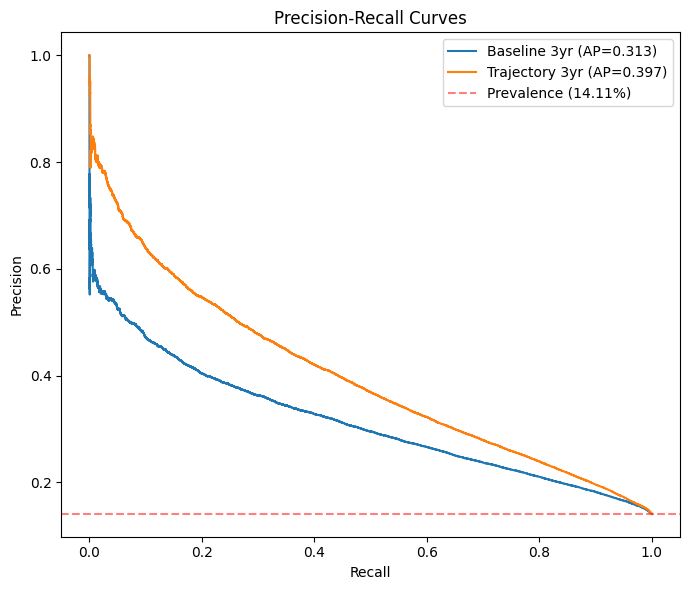

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Use OOF predictions already computed
auprc_base = average_precision_score(y_true_base, preds_base)
auprc_traj = average_precision_score(y_true_traj, preds_traj)

print(f"Baseline 3yr AUPRC:    {auprc_base:.4f}")
print(f"Trajectory 3yr AUPRC:  {auprc_traj:.4f}")

# Plot PR curves
fig, ax = plt.subplots(figsize=(7, 6))

for name, yt, yp in [("Baseline 3yr", y_true_base, preds_base),
                      ("Trajectory 3yr", y_true_traj, preds_traj)]:
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

prevalence = y_true_traj.mean()
ax.axhline(prevalence, color="red", linestyle="--", alpha=0.5,
           label=f"Prevalence ({prevalence:.2%})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend()
plt.tight_layout()
plt.savefig("pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Demographics Extraction

In [78]:
dataset_person_sql = """
SELECT
    p.person_id,
    p.year_of_birth,
    gc.concept_name AS gender
FROM
    `""" + os.environ["WORKSPACE_CDR"] + """.person` p
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` gc
ON
    p.gender_concept_id = gc.concept_id
"""

In [79]:
person_df = pandas.read_gbq(
    dataset_person_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

person_df.shape

Downloading:   0%|          | 0/633547 [00:00<?, ?rows/s]

(633547, 3)

In [80]:
person_df.to_parquet("person_demographics.parquet", index=False)

## Merge Demographics into Pseudo Cohort

In [45]:
person_df = pd.read_parquet("person_demographics.parquet")

cohort_demo = pseudo_cohort.merge(
    person_df,
    on="person_id",
    how="left"
)

cohort_demo.shape

(212145, 5)

In [46]:
# Compute Age at Index
cohort_demo["decline_date"] = pd.to_datetime(cohort_demo["decline_date"])

cohort_demo["age_at_index"] = (
    cohort_demo["decline_date"].dt.year
    - cohort_demo["year_of_birth"]
)

cohort_demo[["age_at_index","gender"]].describe()

,age_at_index
count,212145.0
mean,60.231483
std,11.018383
min,13.0
25%,52.0
50%,60.0
75%,68.0
max,104.0


In [47]:
cohort_demo["gender"].isna().sum()

0

## Demographics-Only Baseline Model

Establishes the predictive floor achievable from age and sex alone, against which lab and trajectory features must improve.

In [34]:
# Build demographics-only dataset
person_df = pd.read_parquet("person_demographics.parquet")

cohort_demo = pseudo_cohort.merge(person_df, on="person_id", how="left")
cohort_demo["decline_date"] = pd.to_datetime(cohort_demo["decline_date"])
cohort_demo["age_at_index"] = cohort_demo["decline_date"].dt.year - cohort_demo["year_of_birth"]

# One-hot encode gender
demo_features = pd.get_dummies(
    cohort_demo[["person_id", "age_at_index", "gender", "label"]],
    columns=["gender"],
    drop_first=True
)

# Clean column names for LightGBM
import re
demo_features.columns = [
    re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in demo_features.columns
]

print("Demographics-only dataset shape:", demo_features.shape)
print("\nAge summary:")
print(cohort_demo["age_at_index"].describe().round(1))
print("\nGender distribution:")
print(cohort_demo["gender"].value_counts())

Demographics-only dataset shape: (212145, 11)

Age summary:
count    212145.0
mean         60.2
std          11.0
min          13.0
25%          52.0
50%          60.0
75%          68.0
max         104.0
Name: age_at_index, dtype: Float64

Gender distribution:
gender
Female                                                            123759
Male                                                               85586
PMI: Skip                                                           1887
Not man only, not woman only, prefer not to answer, or skipped       232
I prefer not to answer                                               194
Gender Identity: Transgender                                         182
Gender Identity: Non Binary                                          163
Gender Identity: Additional Options                                  141
No matching concept                                                    1
Name: count, dtype: int64


In [35]:
# Run CV on demographics-only model
demo_mean, demo_std = run_model_cv(
    demo_features,
    model_name="Demographics Only (Age + Sex)"
)


===== Demographics Only (Age + Sex) =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.6399


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.6320


...

Fold 3: AUC = 0.6348


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.6365


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.6383

Mean AUC: 0.6363 ± 0.0027


In [36]:
# OOF predictions for demographics-only model
y_true_demo, preds_demo = get_oof_predictions(demo_features)

demo_auc_mean, demo_lo, demo_hi = bootstrap_auc_ci(y_true_demo, preds_demo)

print(f"Demographics-only AUC: {demo_auc_mean:.4f} [{demo_lo:.4f} - {demo_hi:.4f}]")

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.635941073493486
Demographics-only AUC: 0.6360 [0.6326 - 0.6393]


## Age/Sex Matched Cohort Design

1:1 matching of cases to controls on gender (exact) and age at index (±2 years) to remove demographic confounding and isolate the contribution of lab trajectory features.

In [38]:
# Prepare cases and controls with demographics
cases_m = cohort_demo[cohort_demo["label"] == 1].copy()
controls_m = cohort_demo[cohort_demo["label"] == 0].copy()

print(f"Cases available for matching: {len(cases_m)}")
print(f"Controls available for matching: {len(controls_m)}")

Cases available for matching: 29537
Controls available for matching: 182608


In [39]:
# 1:1 Greedy matching on gender (exact) and age (±2 years)
# Store explicit case→control mapping for correct index date assignment

cases_m = cases_m.sort_values(["gender", "age_at_index"]).reset_index(drop=True)
controls_m = controls_m.sort_values(["gender", "age_at_index"]).reset_index(drop=True)

matched_pairs = []  # list of (case_person_id, control_person_id, case_decline_date)

available_controls = controls_m.copy()

for _, case in cases_m.iterrows():

    potential = available_controls[
        (available_controls["gender"] == case["gender"]) &
        (abs(available_controls["age_at_index"] - case["age_at_index"]) <= 2)
    ]

    if len(potential) > 0:
        selected = potential.iloc[0]

        matched_pairs.append({
            "case_id": case["person_id"],
            "control_id": selected["person_id"],
            "case_decline_date": case["decline_date"]
        })

        # Remove used control (without replacement)
        available_controls = available_controls[
            available_controls["person_id"] != selected["person_id"]
        ]

match_df = pd.DataFrame(matched_pairs)
print(f"Successfully matched: {len(match_df)} pairs")
print(f"Unmatched cases: {len(cases_m) - len(match_df)}")

Successfully matched: 29532 pairs
Unmatched cases: 5


In [40]:
# Build matched cohort with CORRECT index date assignment via explicit mapping

# Cases: use their real decline dates
matched_cases_df = cases_m[
    cases_m["person_id"].isin(match_df["case_id"])
][["person_id", "decline_date", "label", "age_at_index", "gender"]].copy()

# Controls: assign the MATCHED CASE's decline date (not positional)
control_dates = match_df[["control_id", "case_decline_date"]].rename(
    columns={"control_id": "person_id", "case_decline_date": "decline_date"}
)

matched_controls_df = controls_m[
    controls_m["person_id"].isin(match_df["control_id"])
][["person_id", "label", "age_at_index", "gender"]].copy()

matched_controls_df = matched_controls_df.merge(
    control_dates, on="person_id", how="left"
)

# Combine
matched_cohort = pd.concat(
    [matched_cases_df[["person_id", "decline_date", "label"]],
     matched_controls_df[["person_id", "decline_date", "label"]]],
    ignore_index=True
)

matched_cohort.to_parquet("matched_cohort.parquet", index=False)

print(f"Matched cohort size: {len(matched_cohort)}")
print(f"  Cases:    {(matched_cohort['label']==1).sum()}")
print(f"  Controls: {(matched_cohort['label']==0).sum()}")

Matched cohort size: 59064
  Cases:    29532
  Controls: 29532


In [41]:
# Verify demographic balance after matching
matched_with_demo = matched_cohort.merge(
    cohort_demo[["person_id", "age_at_index", "gender"]],
    on="person_id", how="left"
)

print("Age at index by group:")
print(matched_with_demo.groupby("label")["age_at_index"].describe().round(1))
print("\nGender distribution by group:")
print(pd.crosstab(matched_with_demo["label"], matched_with_demo["gender"], normalize="index").round(3))

Age at index by group:
         count  mean   std   min   25%   50%   75%    max
label                                                    
0      29532.0  62.9  10.9  31.0  55.0  63.0  71.0  100.0
1      29532.0  64.9  10.9  33.0  57.0  65.0  73.0  101.0

Gender distribution by group:
gender  Female  Gender Identity: Additional Options  \
label                                                 
0        0.599                                0.001   
1        0.599                                0.001   

gender  Gender Identity: Non Binary  Gender Identity: Transgender  \
label                                                               
0                             0.001                         0.001   
1                             0.001                         0.001   

gender  I prefer not to answer   Male  \
label                                   
0                        0.001  0.386   
1                        0.001  0.386   

gender  Not man only, not woman only, prefer not to

## Matched Cohort: Trajectory Features and Evaluation

In [42]:
# Merge matched cohort with labs
labs_matched = measurement_df.merge(
    matched_cohort[["person_id", "decline_date", "label"]],
    on="person_id", how="inner"
)

labs_matched["measurement_datetime"] = pd.to_datetime(labs_matched["measurement_datetime"])
labs_matched["decline_date"] = pd.to_datetime(labs_matched["decline_date"])

# Pre-index only
labs_matched = labs_matched[
    labs_matched["measurement_datetime"] < labs_matched["decline_date"]
]

# 3-year window
labs_matched_3yr = labs_matched[
    labs_matched["measurement_datetime"] >=
    labs_matched["decline_date"] - pd.DateOffset(years=3)
].copy()

print("Matched labs 3yr shape:", labs_matched_3yr.shape)

Matched labs 3yr shape: (3886479, 8)


In [43]:
# Trajectory features for matched cohort (with slope)
labs_matched_3yr["days_before_index"] = (
    labs_matched_3yr["decline_date"] - labs_matched_3yr["measurement_datetime"]
).dt.days

labs_matched_3yr = labs_matched_3yr.sort_values(
    ["person_id", "standard_concept_name", "measurement_datetime"]
)

agg_basic_m = (
    labs_matched_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        mean=("value_as_number", "mean"),
        std=("value_as_number", "std"),
        first_val=("value_as_number", "first"),
        last_val=("value_as_number", "last"),
        count=("value_as_number", "count")
    )
)

labs_matched_3yr["xy"] = labs_matched_3yr["days_before_index"] * labs_matched_3yr["value_as_number"]
labs_matched_3yr["xx"] = labs_matched_3yr["days_before_index"] ** 2

agg_slope_m = (
    labs_matched_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        sum_x=("days_before_index", "sum"),
        sum_y=("value_as_number", "sum"),
        sum_xy=("xy", "sum"),
        sum_xx=("xx", "sum"),
        n=("value_as_number", "count")
    )
)

num_m = agg_slope_m["n"] * agg_slope_m["sum_xy"] - agg_slope_m["sum_x"] * agg_slope_m["sum_y"]
den_m = agg_slope_m["n"] * agg_slope_m["sum_xx"] - agg_slope_m["sum_x"] ** 2
agg_slope_m["slope"] = num_m / den_m
agg_slope_m.loc[den_m == 0, "slope"] = np.nan

traj_matched = agg_basic_m.join(agg_slope_m["slope"])
traj_matched["delta"] = traj_matched["last_val"] - traj_matched["first_val"]
traj_matched = traj_matched.reset_index()

# Pivot to wide
traj_m_long = traj_matched.melt(
    id_vars=["person_id", "standard_concept_name"],
    value_vars=["mean", "std", "delta", "slope", "count"],
    var_name="metric", value_name="value"
)
traj_m_long["feature"] = (
    traj_m_long["standard_concept_name"]
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    + "_" + traj_m_long["metric"]
)

traj_matched_wide = traj_m_long.pivot(
    index="person_id", columns="feature", values="value"
).reset_index()

traj_matched_wide = traj_matched_wide.merge(
    labs_matched_3yr[["person_id", "label"]].drop_duplicates(),
    on="person_id"
)

print("Matched trajectory wide shape:", traj_matched_wide.shape)

Matched trajectory wide shape: (50313, 57)


In [49]:
traj_matched_wide.to_parquet("traj_matched_3yr_wide.parquet", index=False)

In [44]:
# CV evaluation on matched cohort
matched_mean, matched_std = run_model_cv(
    traj_matched_wide,
    model_name="Matched Trajectory 3-Year"
)

run_multiple_models_cv(traj_matched_wide, "Matched Trajectory 3yr")


===== Matched Trajectory 3-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7199


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7175


...

/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [23:05:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [23:05:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [23:05:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [23:05:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [23:05:24] WARNING: /w

XGBoost: 0.7145 ± 0.0028


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.7158 ± 0.0034


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
# OOF predictions for matched cohort
y_true_matched, preds_matched = get_oof_predictions(traj_matched_wide)

matched_oof_mean, matched_lo, matched_hi = bootstrap_auc_ci(
    y_true_matched, preds_matched
)

print(f"Matched Trajectory 3yr AUC: {matched_oof_mean:.4f} [{matched_lo:.4f} - {matched_hi:.4f}]")

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7157073432640522
Matched Trajectory 3yr AUC: 0.7157 [0.7113 - 0.7201]


## Net Reclassification Improvement (NRI)

Evaluates whether the trajectory model correctly reclassifies patients compared to the baseline model at clinically relevant risk thresholds.

In [46]:
def compute_nri(y_true, pred_baseline, pred_trajectory, threshold=0.20):
    """Compute category-based NRI from paired OOF predictions."""

    class_b = (pred_baseline >= threshold).astype(int)
    class_t = (pred_trajectory >= threshold).astype(int)

    events = y_true == 1
    nonevents = y_true == 0

    event_up = np.sum((class_t > class_b) & events)
    event_down = np.sum((class_t < class_b) & events)

    nonevent_down = np.sum((class_t < class_b) & nonevents)
    nonevent_up = np.sum((class_t > class_b) & nonevents)

    nri_events = (event_up - event_down) / np.sum(events)
    nri_nonevents = (nonevent_down - nonevent_up) / np.sum(nonevents)

    nri = nri_events + nri_nonevents

    return nri, nri_events, nri_nonevents

print("NRI at various risk thresholds (Trajectory vs Baseline, 3yr):\n")
print(f"{'Threshold':>10}  {'NRI':>8}  {'NRI-events':>12}  {'NRI-nonevents':>14}")
print("-" * 50)
for t in [0.10, 0.15, 0.20, 0.25, 0.30]:
    nri, nri_e, nri_ne = compute_nri(y_true_base, preds_base, preds_traj, threshold=t)
    print(f"{t:>10.2f}  {nri:>8.4f}  {nri_e:>12.4f}  {nri_ne:>14.4f}")

NRI at various risk thresholds (Trajectory vs Baseline, 3yr):

 Threshold       NRI    NRI-events   NRI-nonevents
--------------------------------------------------
      0.10    0.0157       -0.0002          0.0159
      0.15    0.0213       -0.0017          0.0230
      0.20    0.0500       -0.0119          0.0619
      0.25    0.0989       -0.0303          0.1292
      0.30    0.1032       -0.0356          0.1388


## Final Results Summary

In [47]:
# Collect all OOF-based results
auprc_demo = average_precision_score(y_true_demo, preds_demo) if 'y_true_demo' in dir() else float('nan')
auprc_matched = average_precision_score(y_true_matched, preds_matched) if 'y_true_matched' in dir() else float('nan')

results = pd.DataFrame([
    {"Model": "Demographics only",
     "AUC": demo_auc_mean,
     "95% CI": f"[{demo_lo:.3f}-{demo_hi:.3f}]",
     "AUPRC": auprc_demo},
    {"Model": "Baseline labs (3yr)",
     "AUC": base_mean,
     "95% CI": f"[{base_lo:.3f}-{base_hi:.3f}]",
     "AUPRC": auprc_base},
    {"Model": "Trajectory (3yr, unmatched)",
     "AUC": traj_mean,
     "95% CI": f"[{traj_lo:.3f}-{traj_hi:.3f}]",
     "AUPRC": auprc_traj},
    {"Model": "Trajectory (3yr, matched)",
     "AUC": matched_oof_mean,
     "95% CI": f"[{matched_lo:.3f}-{matched_hi:.3f}]",
     "AUPRC": auprc_matched},
])

results["AUC"] = results["AUC"].round(4)
results["AUPRC"] = results["AUPRC"].round(4)

print("=" * 72)
print("  FINAL RESULTS — Predicting Mobility Decline (All of Us, Pseudo-Index)")
print("=" * 72)
print(results.to_string(index=False))
print("=" * 72)

  FINAL RESULTS — Predicting Mobility Decline (All of Us, Pseudo-Index)
                      Model    AUC        95% CI  AUPRC
          Demographics only 0.6360 [0.633-0.639] 0.2197
        Baseline labs (3yr) 0.7266 [0.723-0.730] 0.3126
Trajectory (3yr, unmatched) 0.7708 [0.768-0.774] 0.3968
  Trajectory (3yr, matched) 0.7157 [0.711-0.720] 0.7506


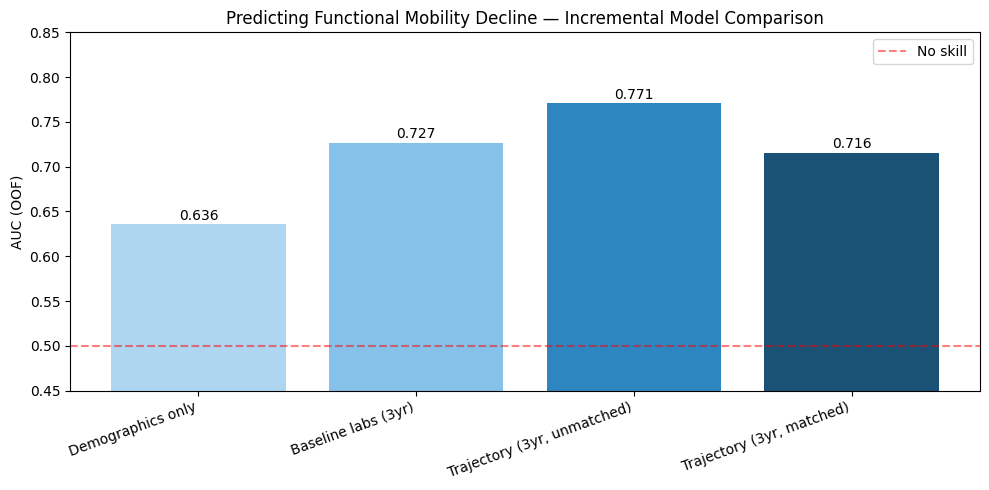

In [48]:
# Final visualization
fig, ax = plt.subplots(figsize=(10, 5))

names = results["Model"].values
aucs = results["AUC"].values

colors = ["#AED6F1", "#85C1E9", "#2E86C1", "#1A5276"]

bars = ax.bar(range(len(names)), aucs, color=colors)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="No skill")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("AUC (OOF)")
ax.set_title("Predicting Functional Mobility Decline — Incremental Model Comparison")
ax.set_ylim(0.45, 0.85)

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005, f"{auc:.3f}",
            ha="center", fontsize=10)

ax.legend()
plt.tight_layout()
plt.savefig("final_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings

1. **Demographics alone** (age + sex) provide a baseline AUC, confirming that age is a strong predictor of mobility decline.

2. **Cross-sectional lab means** improve upon demographics, indicating that routine labs carry independent predictive information.

3. **Longitudinal trajectory features** (slope, delta, variability) further improve discrimination, demonstrating that dynamic changes in lab values over time capture pre-clinical decline signals beyond static snapshots.

4. **After age/sex matching**, performance decreases but remains above baseline, confirming that part of the unmatched signal was demographic confounding, while a meaningful trajectory effect persists.Age and sex contribute meaningful predictive signal, as shown by the decrease in discrimination after age/sex matching. However, trajectory features retain substantial predictive value even after demographic confounding is removed.

5. **Count features** contribute modestly; removing them causes only a small AUC decrease, suggesting the model relies primarily on physiological dynamics rather than healthcare utilization patterns.

## Limitations

- **Outcome ascertainment:** Mobility decline is defined by ICD-10-CM diagnosis codes, which may undercount true functional decline (low sensitivity) and may vary by provider documentation practices.
- **Missing data:** Median imputation was used throughout. Differential missingness between cases and controls was documented but not fully addressed with multiple imputation.
- **Temporal validation:** All evaluations use cross-sectional random splits. A calendar-time split (e.g., train pre-2020, test post-2020) would provide stronger evidence of generalizability.
- **Survivorship bias:** The study population excludes deceased individuals, which may bias toward less severe or later-onset decline.
- **Comorbidity adjustment:** The current models do not adjust for known comorbidities (e.g., diabetes, CKD), which directly affect the lab values used as predictors.
- **Pseudo-index sampling:** Control index dates are sampled uniformly within each control's observation window, rather than from the empirical distribution of case index dates.